In [11]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('https://star.herts.ac.uk/~kuhn/DHV/forest_fires.csv')

data.head()


,region,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,Bejaia,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,Bejaia,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,Bejaia,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,Bejaia,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,Bejaia,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [12]:
data.shape

(244, 15)

In [13]:
data.columns

Index(['region', 'day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain',
       'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='str')

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   region       244 non-null    str    
 1   day          244 non-null    int64  
 2   month        244 non-null    int64  
 3   year         244 non-null    int64  
 4   Temperature  244 non-null    int64  
 5   RH           244 non-null    int64  
 6   Ws           244 non-null    int64  
 7   Rain         244 non-null    float64
 8   FFMC         244 non-null    float64
 9   DMC          244 non-null    float64
 10  DC           244 non-null    float64
 11  ISI          244 non-null    float64
 12  BUI          244 non-null    float64
 13  FWI          244 non-null    float64
 14  Classes      244 non-null    str    
dtypes: float64(7), int64(6), str(2)
memory usage: 28.7 KB


In [15]:
data.isnull().sum()

region         0
day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

In [16]:
data['Classes'].unique()

<StringArray>
['not fire', 'fire']
Length: 2, dtype: str

In [17]:
data['region'].unique()

<StringArray>
['Bejaia', 'SidiBelAbbes']
Length: 2, dtype: str

In [18]:
# let's start with graphs now
# First : Fire vs Not Fire count plot

data['Classes'].value_counts()

Classes
fire        138
not fire    106
Name: count, dtype: int64

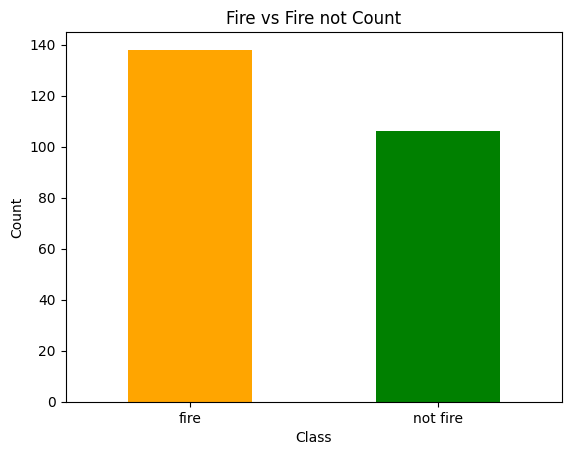

In [27]:
data['Classes'].value_counts().plot(kind='bar',color=['Orange','Green'])
plt.title("Fire vs Fire not Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [36]:
# now i'll check group by region that which region has more fire
region_fire = data.groupby(['region','Classes']).size().unstack()
region_fire

Classes,fire,not fire
region,,
Bejaia,59,63
SidiBelAbbes,79,43


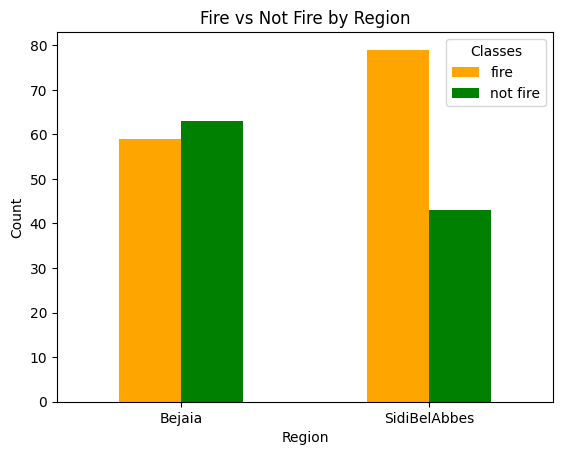

In [52]:
region_fire.plot(kind="bar",color=['orange','green'])
plt.title("Fire vs Not Fire by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

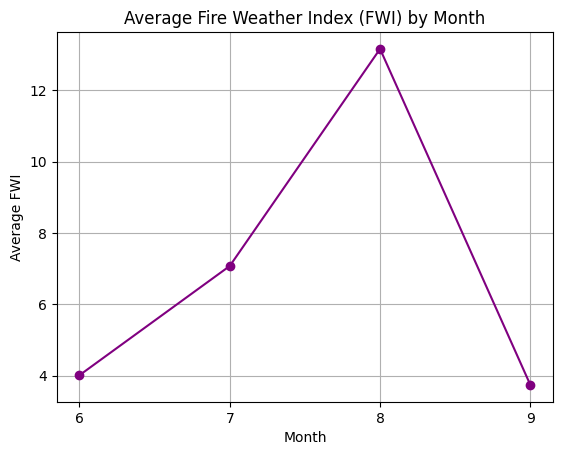

In [53]:
monthly_fwi = data.groupby('month')['FWI'].mean()
monthly_fwi.plot(kind='line', marker='o',color="purple")
plt.title("Average Fire Weather Index (FWI) by Month")
plt.xlabel("Month")
plt.ylabel("Average FWI")
plt.grid(True)
plt.xticks(monthly_fwi.index)
plt.show()

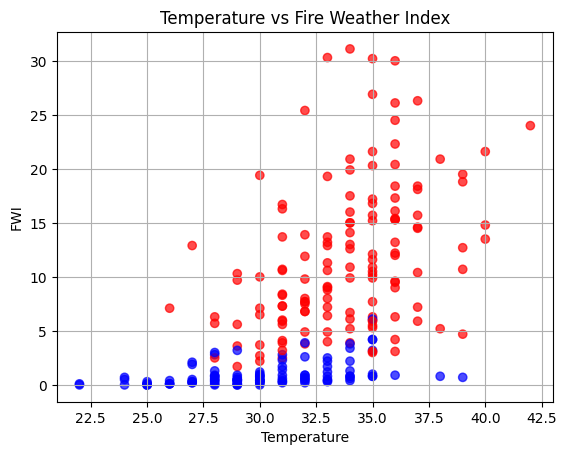

In [66]:
# now final plot Temperature vs Fire Danger (FWI)
colors = data['Classes'].map({'fire': 'red', 'not fire': 'blue'})
plt.scatter(data['Temperature'],data['FWI'],c=colors,alpha=0.7)
plt.title("Temperature vs Fire Weather Index")
plt.xlabel("Temperature")
plt.ylabel("FWI")
plt.grid(True)
plt.show()

The scatter plot shows a positive relationship between temperature and fire weather index. Higher temperatures are generally associated with higher fire risk. Fire events (red points) mostly occur at higher FWI values, while non-fire days (blue points) are concentrated at lower FWI levels.

In [67]:
data.duplicated().sum()

np.int64(0)